<a href="https://colab.research.google.com/github/Rajeraghav/AI-Engineer-Journey/blob/main/Day01/Student_Performance_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving StudentsPerformance.csv to StudentsPerformance.csv
First 5 Records
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Dataset Shape:
(1000, 8)

Missing Values:
gender                         0
race/ethn

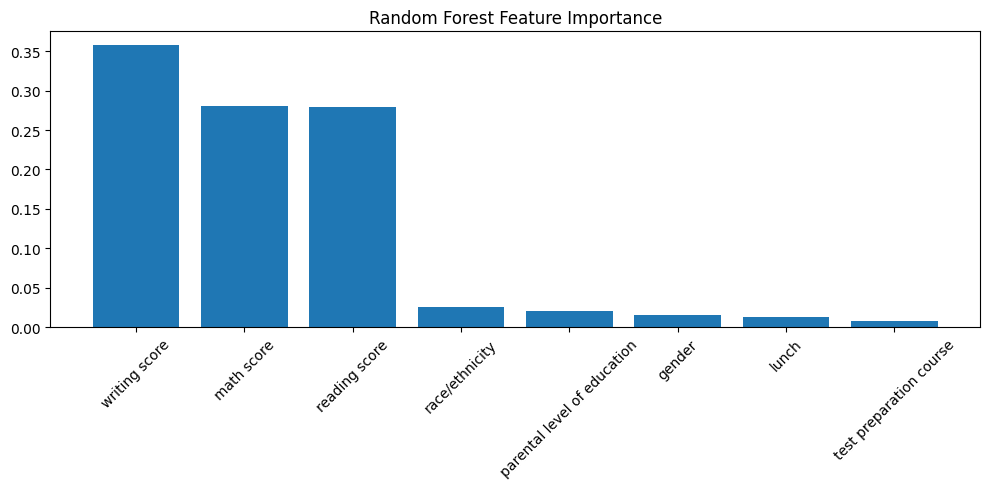


Sample Prediction:
PASS


In [1]:
# ==========================================
# STUDENT PERFORMANCE PREDICTOR
# Benchmark Dataset:
# StudentsPerformance.csv
# ==========================================

# Step 1: Upload Dataset

from google.colab import files

uploaded = files.upload()

# ==========================================
# Step 2: Import Libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# Step 3: Load Dataset
# ==========================================

df = pd.read_csv("StudentsPerformance.csv")

print("First 5 Records")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

# ==========================================
# Step 4: Create Target Variable
# ==========================================

df['average_score'] = (
    df['math score']
    + df['reading score']
    + df['writing score']
) / 3

df['Pass'] = df['average_score'].apply(
    lambda x: 1 if x >= 50 else 0
)

print("\nPass Distribution")
print(df['Pass'].value_counts())

# ==========================================
# Step 5: Encode Categorical Columns
# ==========================================

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# ==========================================
# Step 6: Features and Target
# ==========================================

X = df.drop(
    ['Pass', 'average_score'],
    axis=1
)

y = df['Pass']

# ==========================================
# Step 7: Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Records:", X_train.shape[0])
print("Testing Records :", X_test.shape[0])

# ==========================================
# Step 8: Logistic Regression
# ==========================================

print("\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\nAccuracy:")
print(accuracy_score(y_test, lr_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# ==========================================
# Step 9: Random Forest
# ==========================================

print("\n==============================")
print("RANDOM FOREST")
print("==============================")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nAccuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# ==========================================
# Step 10: Feature Importance
# ==========================================

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
print(feature_importance)

plt.figure(figsize=(10,5))
plt.bar(feature_importance['Feature'],
        feature_importance['Importance'])

plt.xticks(rotation=45)
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

# ==========================================
# Step 11: Sample Prediction
# ==========================================

sample = X.iloc[[0]]

prediction = rf.predict(sample)

print("\nSample Prediction:")

if prediction[0] == 1:
    print("PASS")
else:
    print("FAIL")

In [2]:
import pickle

pickle.dump(rf, open("student_performance_model.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully


In [4]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 53.9 MB/s eta 0:00:00


In [5]:
import pickle

pickle.dump(rf, open("student_performance_model.pkl", "wb"))

In [6]:
%%writefile app.py

import streamlit as st
import pickle
import pandas as pd

model = pickle.load(open("student_performance_model.pkl","rb"))

st.title("Student Performance Predictor")

math_score = st.number_input("Math Score",0,100,50)
reading_score = st.number_input("Reading Score",0,100,50)
writing_score = st.number_input("Writing Score",0,100,50)

test_preparation = st.selectbox(
    "Test Preparation Course",
    ["none","completed"]
)

if test_preparation=="none":
    test_preparation=1
else:
    test_preparation=0

if st.button("Predict"):

    input_data = pd.DataFrame(
        [[0,0,0,0,
          test_preparation,
          math_score,
          reading_score,
          writing_score]],
        columns=[
            'gender',
            'race/ethnicity',
            'parental level of education',
            'lunch',
            'test preparation course',
            'math score',
            'reading score',
            'writing score'
        ]
    )

    prediction = model.predict(input_data)

    if prediction[0]==1:
        st.success("PASS")
    else:
        st.error("FAIL")

Writing app.py


In [7]:
!pip install streamlit

In [8]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
added 22 packages in 4s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹

In [9]:
!streamlit run app.py &>/content/log.txt &

In [ ]:
!npx localtunnel --port 8501

⠙⠹your url is: https://short-carpets-double.loca.lt
